# Depression Detection Pipeline

This notebook contains the same end-to-end workflow as `model.py`, reorganized into a cleaner and more professional structure for notebook-based experimentation.

It is also prepared to run in **Google Colab** as well as in a local Jupyter environment.

## Colab Quick Start

This notebook is designed to run only in Google Colab.

1. Open the notebook in Colab.
2. Change the runtime to `T4 GPU`.
3. Run the setup cell to install the notebook dependencies without replacing Colab's GPU-enabled PyTorch.
4. Run the Google Drive setup cell and approve Drive access.
5. Upload `dataset.csv` when prompted if it is not already stored in the Drive project folder.
6. Run the remaining cells from top to bottom.

All trained artifacts are saved to `/content/drive/MyDrive/depression_project`.


In [1]:
try:
    import google.colab  # type: ignore
except ImportError as exc:
    raise EnvironmentError("This notebook is intended to run only in Google Colab.") from exc

# Keep Colab's preinstalled CUDA-enabled PyTorch. Installing torch here can replace it with a CPU-only build.
%pip install -q pandas numpy scikit-learn==1.8.0 joblib matplotlib seaborn transformers accelerate


## 1. Google Drive and Project Paths

This section mounts Google Drive, defines the Colab project folder, and ensures the dataset and outputs live in persistent storage.


In [2]:
from pathlib import Path
from google.colab import drive, files  # type: ignore

drive.mount('/content/drive')
BASE_DIR = Path('/content/drive/MyDrive/depression_project')
BASE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = BASE_DIR / "dataset.csv"
CLASSICAL_MODEL_PATH = BASE_DIR / "depression_model.pkl"
VECTORIZER_PATH = BASE_DIR / "tfidf_vectorizer.pkl"
TRANSFORMER_OUTPUT_DIR = BASE_DIR / "distilbert_depression_model"
TRANSFORMER_RESULTS_DIR = BASE_DIR / "transformer_results"
LOGS_DIR = BASE_DIR / "logs"

TRANSFORMER_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.exists():
    print("Upload dataset.csv to continue.")
    uploaded = files.upload()
    if "dataset.csv" not in uploaded:
        raise FileNotFoundError("dataset.csv was not uploaded to the Colab runtime.")
    DATASET_PATH.write_bytes(uploaded["dataset.csv"])

print("Google Drive project folder:", BASE_DIR)
print("Dataset path:", DATASET_PATH)
print("Classical model path:", CLASSICAL_MODEL_PATH)
print("Transformer output dir:", TRANSFORMER_OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive project folder: /content/drive/MyDrive/depression_project
Dataset path: /content/drive/MyDrive/depression_project/dataset.csv
Classical model path: /content/drive/MyDrive/depression_project/depression_model.pkl
Transformer output dir: /content/drive/MyDrive/depression_project/distilbert_depression_model


## 2. Environment Setup

Import the required libraries for data preparation, classical machine learning, and evaluation.

In [3]:
import inspect
import re

import matplotlib.pyplot as plt

import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.svm import SVC


## 3. Data Loading and Label Preparation

Load the dataset and convert the target labels into a binary representation suitable for model training.

In [4]:
df = pd.read_csv(DATASET_PATH)

df["depressed"] = df["depressed"].astype(str).str.upper().map({"YES": 1, "NO": 0})
df = df.dropna(subset=["depressed"]).copy()
df["depressed"] = df["depressed"].astype(int)


## 4. Exploratory Data Checks

Perform a quick inspection of dataset size and class balance before training.

In [5]:
print("Dataset Shape:", df.shape)
print(df["depressed"].value_counts())


Dataset Shape: (37867, 2)
depressed
1    23012
0    14855
Name: count, dtype: int64


## 5. Text Preprocessing

Define a lightweight preprocessing function for the classical machine learning models. The transformer pipeline will still use the original raw text.

In [6]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text


df["Text"] = df["Text"].fillna("").astype(str)
df["clean_text"] = df["Text"].apply(preprocess)


## 6. Train-Test Split

Keep both raw text and cleaned text so the notebook supports traditional ML and transformer training within the same workflow.

In [7]:
X_raw = df["Text"]
X = df["clean_text"]
y = df["depressed"]

X_train_raw, X_test_raw, X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)


## 7. Classical Machine Learning Pipeline

This section builds TF-IDF features, trains baseline models, performs tuning, and saves the best classical ML artifacts.

### 7.1 TF-IDF Vectorization

In [8]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


### 7.2 Baseline Model Training

In [9]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_tfidf, y_train)

svm_model = SVC(kernel="linear", class_weight="balanced", probability=True)
svm_model.fit(X_train_tfidf, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 7.3 Evaluation Utilities

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay


def evaluate(model, X_test_data, y_test_data, name):
    preds = model.predict(X_test_data)
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test_data, preds))
    print("\nClassification Report:\n", classification_report(y_test_data, preds))

    cm = confusion_matrix(y_test_data, preds)
    print("Confusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

### 7.4 Baseline Evaluation, Cross-Validation, and Tuning

This section evaluates the baseline Logistic Regression and SVM models, runs cross-validation for Logistic Regression, and tunes Logistic Regression for the final classical comparison.


===== Logistic Regression =====
Accuracy: 0.9070504357010827

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.89      2971
           1       0.95      0.90      0.92      4603

    accuracy                           0.91      7574
   macro avg       0.90      0.91      0.90      7574
weighted avg       0.91      0.91      0.91      7574

Confusion Matrix:
 [[2745  226]
 [ 478 4125]]


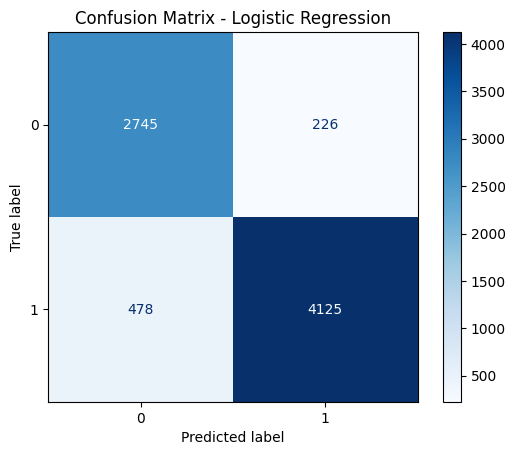


===== SVM =====
Accuracy: 0.9063902825455505

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      2971
           1       0.94      0.90      0.92      4603

    accuracy                           0.91      7574
   macro avg       0.90      0.91      0.90      7574
weighted avg       0.91      0.91      0.91      7574

Confusion Matrix:
 [[2708  263]
 [ 446 4157]]


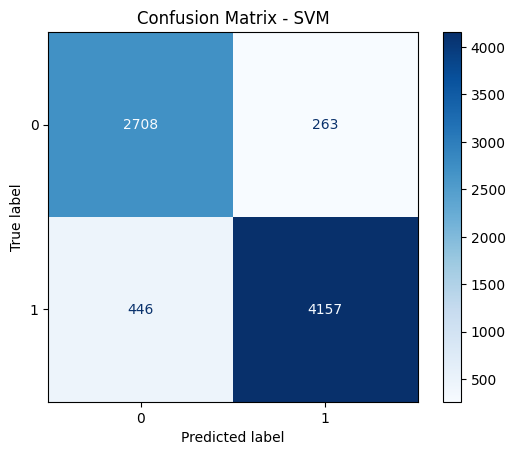


Cross Validation (Logistic Regression)
[0.91753156 0.92232739 0.91606247 0.91290955 0.92469838]
Mean F1: 0.9187 | Std: 0.0043
Best Logistic Regression Params: {'C': 10}

===== Tuned Logistic Regression =====
Accuracy: 0.906522313176657

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      2971
           1       0.94      0.91      0.92      4603

    accuracy                           0.91      7574
   macro avg       0.90      0.91      0.90      7574
weighted avg       0.91      0.91      0.91      7574

Confusion Matrix:
 [[2690  281]
 [ 427 4176]]


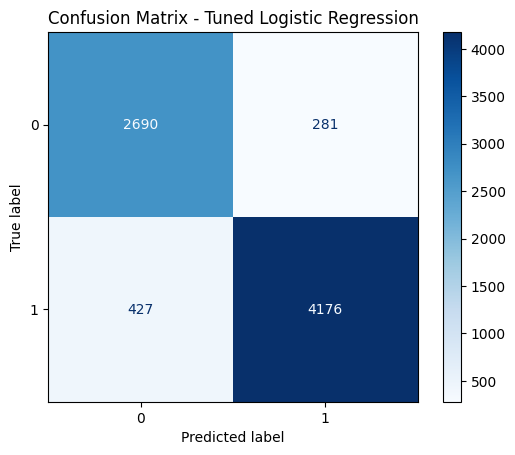

,accuracy,precision,recall,f1
Tuned Logistic Regression,0.906522,0.936953,0.907234,0.921854
SVM,0.906390,0.940498,0.903107,0.921423


Selected classical model: Tuned Logistic Regression


In [11]:
evaluate(log_model, X_test_tfidf, y_test, "Logistic Regression")
evaluate(svm_model, X_test_tfidf, y_test, "SVM")

classical_cv_scores = {
    "Logistic Regression": cross_val_score(log_model, X_train_tfidf, y_train, cv=5, scoring="f1"),
}

for model_name, scores in classical_cv_scores.items():
    print(f"\nCross Validation ({model_name})")
    print(scores)
    print(f"Mean F1: {scores.mean():.4f} | Std: {scores.std():.4f}")

log_param_grid = {"C": [0.1, 1, 10]}

log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    log_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
)

log_grid.fit(X_train_tfidf, y_train)

best_log_model = log_grid.best_estimator_

print("Best Logistic Regression Params:", log_grid.best_params_)

evaluate(best_log_model, X_test_tfidf, y_test, "Tuned Logistic Regression")

classical_model_candidates = {
    "Tuned Logistic Regression": best_log_model,
    "SVM": svm_model,
}

classical_model_metrics = {}

for model_name, model in classical_model_candidates.items():
    preds = model.predict(X_test_tfidf)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        preds,
        average="binary",
        zero_division=0,
    )
    classical_model_metrics[model_name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

classical_metrics_df = pd.DataFrame(classical_model_metrics).T.sort_values(
    by=["f1", "accuracy"],
    ascending=False,
)
display(classical_metrics_df)

best_classical_model_name = classical_metrics_df.index[0]
best_model = classical_model_candidates[best_classical_model_name]
print("Selected classical model:", best_classical_model_name)


### 7.5 Save Classical ML Artifacts and Run a Sample Prediction

In [12]:
joblib.dump(best_model, CLASSICAL_MODEL_PATH)
joblib.dump(vectorizer, VECTORIZER_PATH)
print("Saved classical model:", best_classical_model_name)


def predict(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])
    pred = best_model.predict(vec)[0]
    prob = best_model.predict_proba(vec)[0]
    return pred, prob


print(predict("I feel very sad and lonely"))


Saved classical model: Tuned Logistic Regression
(np.int64(0), array([0.77309304, 0.22690696]))


## 8. Transformer-Based Pipeline

This section reproduces the transformer workflow from `model.py` using DistilBERT for a lighter and more practical text classification setup.

### 8.1 Transformer Dependencies and Configuration

This section verifies that the Colab GPU is visible to PyTorch and configures the transformer training run.


In [13]:
try:
    import torch
    from torch.utils.data import Dataset
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        DataCollatorWithPadding,
        Trainer,
        TrainingArguments,
        set_seed,
    )
except ImportError as exc:
    raise ImportError(
        "Install the transformer dependencies to run the transformer section."
    ) from exc

TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
LABEL_MAP = {0: "NO", 1: "YES"}

set_seed(42)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
if torch.cuda.is_available():
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = True
    print("GPU device:", torch.cuda.get_device_name(0))
    print("cuDNN benchmark:", getattr(torch.backends.cudnn, "benchmark", None))
else:
    print("GPU is not available to PyTorch. Use Runtime > Change runtime type > T4 GPU, then restart the runtime.")


Torch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU device: Tesla T4
cuDNN benchmark: True


### 8.2 Dataset Wrapper and Raw Text Preparation

In [14]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.labels = list(labels)
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            max_length=max_length,
            padding=False,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item["labels"] = int(self.labels[idx])
        return item


X_train_transformer = X_train_raw.tolist()
X_test_transformer = X_test_raw.tolist()
y_train_transformer = y_train.tolist()
y_test_transformer = y_test.tolist()


### 8.3 Tokenizer, Model, and Datasets

In [15]:
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME, use_fast=True)
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=2,
    id2label=LABEL_MAP,
    label2id={label: idx for idx, label in LABEL_MAP.items()},
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)
train_dataset = TextDataset(X_train_transformer, y_train_transformer, tokenizer)
test_dataset = TextDataset(X_test_transformer, y_test_transformer, tokenizer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 8.4 Training Arguments and Metrics

This block keeps the compatibility handling from `model.py`, which helps the notebook remain usable across different `transformers` versions in Colab or local environments.

In [16]:
use_cuda = torch.cuda.is_available()
train_batch_size = 32 if use_cuda else 8
eval_batch_size = 64 if use_cuda else 16
dataloader_workers = 2 if use_cuda else 0
training_args_signature = inspect.signature(TrainingArguments.__init__).parameters

training_args_kwargs = {
    "output_dir": str(TRANSFORMER_RESULTS_DIR),
    "overwrite_output_dir": True,
    "learning_rate": 2e-5,
    "num_train_epochs": 2 if use_cuda else 1,
    "per_device_train_batch_size": train_batch_size,
    "per_device_eval_batch_size": eval_batch_size,
    "warmup_ratio": 0.06,
    "weight_decay": 0.01,
    "logging_dir": str(LOGS_DIR),
    "logging_strategy": "epoch",
    "save_strategy": "epoch",
    "save_total_limit": 1,
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "greater_is_better": True,
    "report_to": "none",
    "dataloader_num_workers": dataloader_workers,
    "dataloader_pin_memory": use_cuda,
    "dataloader_persistent_workers": use_cuda,
    "fp16": use_cuda,
    "gradient_accumulation_steps": 1,
    "group_by_length": True,
    "seed": 42,
    "data_seed": 42,
}

if "eval_strategy" in training_args_signature:
    training_args_kwargs["eval_strategy"] = "epoch"
else:
    training_args_kwargs["evaluation_strategy"] = "epoch"

training_args_kwargs = {
    key: value for key, value in training_args_kwargs.items() if key in training_args_signature
}

training_args = TrainingArguments(**training_args_kwargs)

print(
    {
        "device": "GPU" if use_cuda else "CPU",
        "train_batch_size": train_batch_size,
        "eval_batch_size": eval_batch_size,
        "dataloader_workers": dataloader_workers,
        "fp16": use_cuda,
    }
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0,
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


{'device': 'GPU', 'train_batch_size': 32, 'eval_batch_size': 64, 'dataloader_workers': 2, 'fp16': True}


### 8.5 Trainer Construction

In [ ]:
trainer_kwargs = {
    "model": transformer_model,
    "args": training_args,
    "train_dataset": train_dataset,
    "eval_dataset": test_dataset,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
}

if "processing_class" in inspect.signature(Trainer.__init__).parameters:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

### 8.6 Transformer Training, Evaluation, and Saving

In [ ]:
print(f"Starting transformer training on {'GPU' if use_cuda else 'CPU'}...")
train_output = trainer.train()
train_metrics = train_output.metrics

results = trainer.evaluate()

print("Transformer Results:")
for key, value in results.items():
    print(f"{key} -> {value:.4f}" if isinstance(value, float) else f"{key} -> {value}")

trainer.save_model(str(TRANSFORMER_OUTPUT_DIR))
tokenizer.save_pretrained(str(TRANSFORMER_OUTPUT_DIR))

Starting transformer training on GPU...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.178527,0.087007,0.968577,0.973909,0.982961,0.965023
2,0.061257,0.081217,0.974254,0.978747,0.982065,0.975451


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Transformer Results:
eval_loss -> 0.0812
eval_accuracy -> 0.9743
eval_f1 -> 0.9787
eval_precision -> 0.9821
eval_recall -> 0.9755
eval_runtime -> 2.1844
eval_samples_per_second -> 3467.3850
eval_steps_per_second -> 54.4780
epoch -> 2.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/depression_project/distilbert_depression_model/tokenizer_config.json',
 '/content/drive/MyDrive/depression_project/distilbert_depression_model/tokenizer.json')

### 8.7 Transformer Inference Helper

In [19]:
def transformer_predict(text):
    transformer_model.eval()
    device = transformer_model.device
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = transformer_model(**inputs)

    logits = outputs.logits
    probs = torch.nn.functional.softmax(logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy()[0]


def bert_predict(text):
    return transformer_predict(text)


print(transformer_predict("I feel completely hopeless and alone"))


(0, array([0.9486325 , 0.05136751], dtype=float32))


## 9. Model Accuracy Comparison

This section compares the test accuracy of the classical models and the transformer model.

,Model,Accuracy
2,Transformer,0.974254
0,Tuned Logistic Regression,0.906522
1,SVM,0.906390


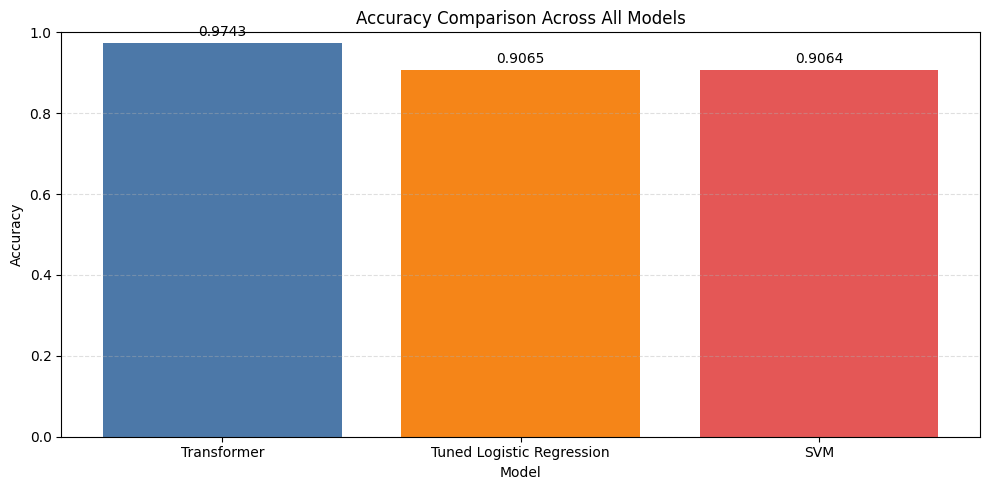

In [20]:
classical_accuracies = {
    model_name: metrics["accuracy"]
    for model_name, metrics in classical_model_metrics.items()
}

transformer_accuracy = results["eval_accuracy"]

accuracy_summary = {
    **classical_accuracies,
    "Transformer": transformer_accuracy,
}

accuracy_df = pd.DataFrame(
    {
        "Model": list(accuracy_summary.keys()),
        "Accuracy": list(accuracy_summary.values()),
    }
).sort_values(by="Accuracy", ascending=False)

display(accuracy_df)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"],
    color=["#4C78A8", "#F58518", "#E45756"],
)
plt.ylim(0.0, 1.0)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Accuracy Comparison Across All Models")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


## 10. Summary

This notebook preserves the logic from `model.py`, but organizes it into a more polished notebook format with clear sections, Colab-friendly setup, and cleaner execution flow.